# Compas Analysis

What follows are the calculations performed for ProPublica's analaysis of the COMPAS Recidivism Risk Scores. It might be helpful to open [the methodology](https://www.propublica.org/article/how-we-analyzed-the-compas-recidivism-algorithm/) in another tab to understand the following.

## Loading the Data

We select fields for severity of charge, number of priors, demographics, age, sex, compas scores, and whether each person was accused of a crime within two years.

## **Acknowledgment**

### In the process of completing the assignment 1 was used Generative AI specificaly Claude to fix parts of my code and writing correctly REALME file in the GitHub repository. To be more precise in the code part it helped me with fixing the problem in the code after appeared errors, while running the code.


In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Define the data source
url = "https://raw.githubusercontent.com/propublica/compas-analysis/master/compas-scores-two-years.csv"

data = pd.read_csv(url)

len(data)

7214

In [3]:
data.head(10)

,id,name,first,last,compas_screening_date,sex,dob,age,age_cat,race,...,v_decile_score,v_score_text,v_screening_date,in_custody,out_custody,priors_count.1,start,end,event,two_year_recid
0,1,miguel hernandez,miguel,hernandez,2013-08-14,Male,1947-04-18,69,Greater than 45,Other,...,1,Low,2013-08-14,2014-07-07,2014-07-14,0,0,327,0,0
1,3,kevon dixon,kevon,dixon,2013-01-27,Male,1982-01-22,34,25 - 45,African-American,...,1,Low,2013-01-27,2013-01-26,2013-02-05,0,9,159,1,1
2,4,ed philo,ed,philo,2013-04-14,Male,1991-05-14,24,Less than 25,African-American,...,3,Low,2013-04-14,2013-06-16,2013-06-16,4,0,63,0,1
3,5,marcu brown,marcu,brown,2013-01-13,Male,1993-01-21,23,Less than 25,African-American,...,6,Medium,2013-01-13,NaN,NaN,1,0,1174,0,0
4,6,bouthy pierrelouis,bouthy,pierrelouis,2013-03-26,Male,1973-01-22,43,25 - 45,Other,...,1,Low,2013-03-26,NaN,NaN,2,0,1102,0,0
5,7,marsha miles,marsha,miles,2013-11-30,Male,1971-08-22,44,25 - 45,Other,...,1,Low,2013-11-30,2013-11-30,2013-12-01,0,1,853,0,0
6,8,edward riddle,edward,riddle,2014-02-19,Male,1974-07-23,41,25 - 45,Caucasian,...,2,Low,2014-02-19,2014-03-31,2014-04-18,14,5,40,1,1
7,9,steven stewart,steven,stewart,2013-08-30,Male,1973-02-25,43,25 - 45,Other,...,3,Low,2013-08-30,2014-05-22,2014-06-03,3,0,265,0,0
8,10,elizabeth thieme,elizabeth,thieme,2014-03-16,Female,1976-06-03,39,25 - 45,Caucasian,...,1,Low,2014-03-16,2014-03-15,2014-03-18,0,2,747,0,0
9,13,bo bradac,bo,bradac,2013-11-04,Male,1994-06-10,21,Less than 25,Caucasian,...,5,Medium,2013-11-04,2015-01-06,2015-01-07,1,0,428,1,1


In [4]:
# Define variable groups
numeric_vars = ["age", "priors_count", "days_b_screening_arrest", "decile_score"]
datetime_vars = ["c_jail_in", "c_jail_out"]

# Select columns (equivalent to dplyr::select)
columns_to_keep = ["age", "c_charge_degree", "race", "age_cat", "score_text",
                   "sex", "priors_count", "days_b_screening_arrest",
                   "decile_score", "is_recid", "two_year_recid",
                   "c_jail_in", "c_jail_out"]

df = data[columns_to_keep].copy()

# Filtering (equivalent to filter())
df = df[df["days_b_screening_arrest"].between(-30, 30)]
df = df[df["is_recid"] != -1]
df = df[df["c_charge_degree"] != "O"]
df = df[df["score_text"] != "N/A"]

# Type conversions
# Convert datetime columns
for col in datetime_vars:
    df[col] = pd.to_datetime(df[col], format="%Y-%m-%d %H:%M:%S", utc=True)

# Convert non-numeric/non-datetime columns to categorical (equivalent to as.factor)
factor_cols = [c for c in df.columns if c not in numeric_vars + datetime_vars]
for col in factor_cols:
    df[col] = df[col].astype("category")

# Derived factors with reference levels
# crime_factor
df["crime_factor"] = df["c_charge_degree"].astype("category")

# age_factor with reference level "25 - 45"
df["age_factor"] = pd.Categorical(df["age_cat"])
df["age_factor"] = df["age_factor"].cat.reorder_categories(
    ["25 - 45"] + [c for c in df["age_factor"].cat.categories if c != "25 - 45"]
)

# race_factor with reference level "Caucasian"
df["race_factor"] = pd.Categorical(df["race"])
df["race_factor"] = df["race_factor"].cat.reorder_categories(
    ["Caucasian"] + [c for c in df["race_factor"].cat.categories if c != "Caucasian"]
)

# gender_factor with labels and reference level "Male"
df["gender_factor"] = df["sex"].map({"Female": "Female", "Male": "Male"}).astype("category")
df["gender_factor"] = df["gender_factor"].cat.reorder_categories(["Male", "Female"])

# score_factor: Low vs High score
df["score_factor"] = pd.Categorical(
    df["score_text"].apply(lambda x: "LowScore" if x == "Low" else "HighScore"),
    categories=["LowScore", "HighScore"]
)

# Row count
len(df)

6172

In [5]:
# See first 10 rows
df.head()

,age,c_charge_degree,race,age_cat,score_text,sex,priors_count,days_b_screening_arrest,decile_score,is_recid,two_year_recid,c_jail_in,c_jail_out,crime_factor,age_factor,race_factor,gender_factor,score_factor
0,69,F,Other,Greater than 45,Low,Male,0,-1.0,1,0,0,2013-08-13 06:03:42+00:00,2013-08-14 05:41:20+00:00,F,Greater than 45,Other,Male,LowScore
1,34,F,African-American,25 - 45,Low,Male,0,-1.0,3,1,1,2013-01-26 03:45:27+00:00,2013-02-05 05:36:53+00:00,F,25 - 45,African-American,Male,LowScore
2,24,F,African-American,Less than 25,Low,Male,4,-1.0,4,1,1,2013-04-13 04:58:34+00:00,2013-04-14 07:02:04+00:00,F,Less than 25,African-American,Male,LowScore
5,44,M,Other,25 - 45,Low,Male,0,0.0,1,0,0,2013-11-30 04:50:18+00:00,2013-12-01 12:28:56+00:00,M,25 - 45,Other,Male,LowScore
6,41,F,Caucasian,25 - 45,Medium,Male,14,-1.0,6,1,1,2014-02-18 05:08:24+00:00,2014-02-24 12:18:30+00:00,F,25 - 45,Caucasian,Male,HighScore


In [6]:
# Shows type, number of data and other information for each variable
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6172 entries, 0 to 7213
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   age                      6172 non-null   int64              
 1   c_charge_degree          6172 non-null   category           
 2   race                     6172 non-null   category           
 3   age_cat                  6172 non-null   category           
 4   score_text               6172 non-null   category           
 5   sex                      6172 non-null   category           
 6   priors_count             6172 non-null   int64              
 7   days_b_screening_arrest  6172 non-null   float64            
 8   decile_score             6172 non-null   int64              
 9   is_recid                 6172 non-null   category           
 10  two_year_recid           6172 non-null   category           
 11  c_jail_in                6172 non-n

In [7]:
# Calculate the length of stay in days
df["length_of_stay"] = (df["c_jail_out"] - df["c_jail_in"]).dt.days

# Calculate correlation
df["length_of_stay"].corr(df["decile_score"])

np.float64(0.20747808478031807)

In [8]:
# Counts number of people of each age range given in the data
df["age_cat"].value_counts()

,count
age_cat,
25 - 45,3532
Less than 25,1347
Greater than 45,1293


In [9]:
# Counts number of people in each race given in the data
df["race"].value_counts()

,count
race,
African-American,3175
Caucasian,2103
Hispanic,509
Other,343
Asian,31
Native American,11


In [10]:
# Prints ratio of each race in the given dataset

print("Black defendants: %.2f%%" %            (3175 / 6172 * 100))
print("White defendants: %.2f%%" %            (2103 / 6172 * 100))
print("Hispanic defendants: %.2f%%" %         (509  / 6172 * 100))
print("Asian defendants: %.2f%%" %            (31   / 6172 * 100))
print("Native American defendants: %.2f%%" %  (11   / 6172 * 100))

Black defendants: 51.44%
White defendants: 34.07%
Hispanic defendants: 8.25%
Asian defendants: 0.50%
Native American defendants: 0.18%


In [11]:
# Counts number of people with different score text
df["score_text"].value_counts()

,count
score_text,
Low,3421
Medium,1607
High,1144


In [12]:
# Cross-tabulation of sex and race
pd.crosstab(df["sex"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
sex,,,,,,
Female,549,2,482,82,2,58
Male,2626,29,1621,427,9,285


In [13]:
# Count of each sex category
df["sex"].value_counts()

,count
sex,
Male,4997
Female,1175


In [14]:
# Print ratio of men and women in the dataset
print("Men: %.2f%%" %   (4997 / 6172 * 100))
print("Women: %.2f%%" % (1175 / 6172 * 100))

Men: 80.96%
Women: 19.04%


In [15]:
# Count of defendants who recidivated within two years
len(df[df["two_year_recid"] == 1])

2809

In [16]:
# Percentage of defendants who recidivated
len(df[df["two_year_recid"] == 1]) / len(df) * 100

45.51198963058976

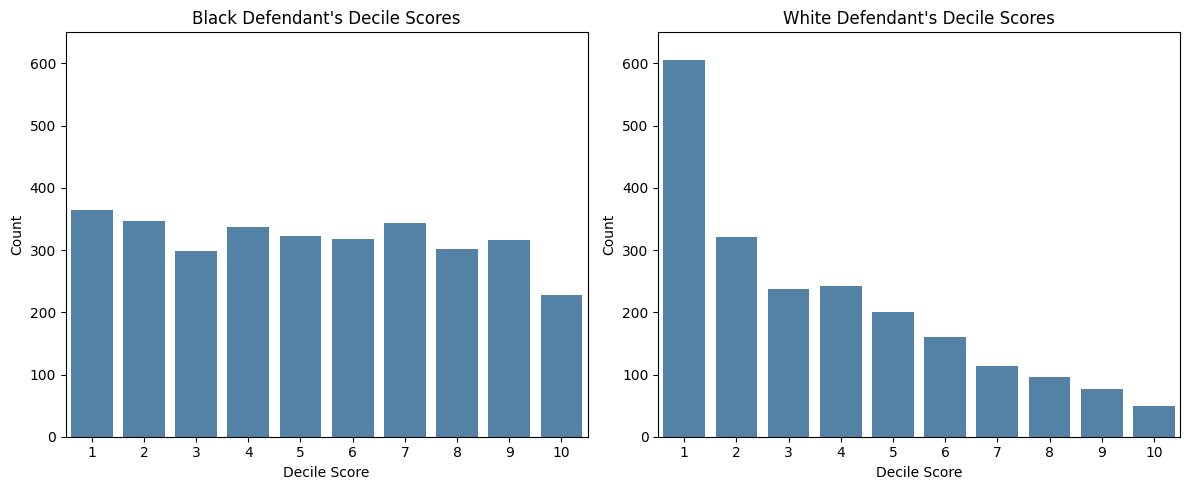

In [17]:
# Create side-by-side subplots (equivalent to grid.arrange(..., ncol=2))
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left plot: Black Defendants (equivalent to pblack)
black_df = df[df["race"] == "African-American"]
sns.countplot(data=black_df, x="decile_score", ax=axes[0], color="steelblue")
axes[0].set_xlabel("Decile Score")
axes[0].set_ylabel("Count")
axes[0].set_ylim(0, 650)
axes[0].set_title("Black Defendant's Decile Scores")

# Right plot: White Defendants (equivalent to pwhite)
white_df = df[df["race"] == "Caucasian"]
sns.countplot(data=white_df, x="decile_score", ax=axes[1], color="steelblue")
axes[1].set_xlabel("Decile Score")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, 650)
axes[1].set_title("White Defendant's Decile Scores")

plt.tight_layout()
plt.show()

In [18]:
pd.crosstab(df["decile_score"], df["race"])

race,African-American,Asian,Caucasian,Hispanic,Native American,Other
decile_score,,,,,,
1,365,15,605,159,0,142
2,346,4,321,89,2,60
3,298,5,238,73,1,32
4,337,0,243,47,0,39
5,323,1,200,39,0,19
6,318,2,160,27,2,20
7,343,1,113,28,2,9
8,301,2,96,14,0,7
9,317,0,77,17,2,7


In [19]:
# Import more specific for this part libraries
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Using GLM with Binomial family (exactly like R's glm)
model_glm = smf.glm(
    formula="score_factor ~ gender_factor + age_factor + race_factor + priors_count + crime_factor + two_year_recid",
    data=df,
    family=sm.families.Binomial(link=sm.families.links.Logit())
).fit()

print(model_glm.summary())

                                   Generalized Linear Model Regression Results                                   
Dep. Variable:     ['score_factor[LowScore]', 'score_factor[HighScore]']   No. Observations:                 6172
Model:                                                               GLM   Df Residuals:                     6160
Model Family:                                                   Binomial   Df Model:                           11
Link Function:                                                     Logit   Scale:                          1.0000
Method:                                                             IRLS   Log-Likelihood:                -3084.2
Date:                                                   Sun, 29 Mar 2026   Deviance:                       6168.4
Time:                                                           06:31:25   Pearson chi2:                 6.07e+03
No. Iterations:                                                        6   Pseudo R-squ.

In [20]:
# Calculate baseline probability from intercept (logistic function)
control = np.exp(-1.52554) / (1 + np.exp(-1.52554))

# Calculate relative risk / probability ratio
np.exp(0.47721) / (1 - control + (control * np.exp(0.47721)))

np.float64(1.4528408658138932)

In [21]:
# Convert odds ratio to relative risk for coefficient 0.22127
np.exp(0.22127) / (1 - control + (control * np.exp(0.22127)))

np.float64(1.1947978508506671)

In [22]:
# Convert odds ratio to relative risk for coefficient 1.30839
np.exp(1.30839) / (1 - control + (control * np.exp(1.30839)))

np.float64(2.4961202077189455)

In [23]:
df["pred_prob"] = model_glm.predict(df)

# Add predicted class based on 0.5 threshold (equivalent to ifelse + factor)
df["pred_class"] = pd.Categorical(
    df["pred_prob"].apply(lambda x: "Recid" if x >= 0.5 else "No Recid"),
    categories=["No Recid", "Recid"]
)

In [24]:
# Import more specific for this part libraries
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

print("Overall Confusion Matrix")

# Create confusion matrix (equivalent to table(Predicted, Actual))
overall_cm = pd.crosstab(
    df["pred_class"],
    df["two_year_recid"],
    rownames=["Predicted"],
    colnames=["Actual"]
)
print(overall_cm)

# Extract TP, TN, FP, FN
TP = overall_cm.loc["Recid", 1]
TN = overall_cm.loc["No Recid", 0]
FP = overall_cm.loc["Recid", 0]
FN = overall_cm.loc["No Recid", 1]
n = overall_cm.values.sum()

# Print metrics
print(f"\nAccuracy  : {(TP + TN) / n:.3f}")
print(f"Precision : {TP / (TP + FP):.3f}")
print(f"Recall    : {TP / (TP + FN):.3f}")
print(f"FPR       : {FP / (FP + TN):.3f}")
print(f"FNR       : {FN / (FN + TP):.3f}")

Overall Confusion Matrix
Actual        0     1
Predicted            
No Recid    710  1864
Recid      2653   945

Accuracy  : 0.268
Precision : 0.263
Recall    : 0.336
FPR       : 0.789
FNR       : 0.664


In [25]:
print("Confusion Matrix by Race")

# Create binary columns for actual and predicted
df["actual"] = df["two_year_recid"].astype(int)
df["pred"] = (df["pred_class"] == "Recid").astype(int)

# Calculate metrics by race (equivalent to group_by + summarise)
race_metrics = df.groupby("race").apply(
    lambda g: pd.Series({
        "n": len(g),
        "TP": ((g["pred"] == 1) & (g["actual"] == 1)).sum(),
        "TN": ((g["pred"] == 0) & (g["actual"] == 0)).sum(),
        "FP": ((g["pred"] == 1) & (g["actual"] == 0)).sum(),
        "FN": ((g["pred"] == 0) & (g["actual"] == 1)).sum(),
    })
).reset_index()

# Calculate derived metrics
race_metrics["Accuracy"] = ((race_metrics["TP"] + race_metrics["TN"]) / race_metrics["n"]).round(3)
race_metrics["Precision"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FP"])).round(3)
race_metrics["Recall"] = (race_metrics["TP"] / (race_metrics["TP"] + race_metrics["FN"])).round(3)
race_metrics["FPR"] = (race_metrics["FP"] / (race_metrics["FP"] + race_metrics["TN"])).round(3)
race_metrics["FNR"] = (race_metrics["FN"] / (race_metrics["FN"] + race_metrics["TP"])).round(3)

# Sort by n descending (equivalent to arrange(desc(n)))
race_metrics = race_metrics.sort_values("n", ascending=False).reset_index(drop=True)

print(race_metrics)

Confusion Matrix by Race
               race     n   TP   TN    FP    FN  Accuracy  Precision  Recall  \
0  African-American  3175  288  555   959  1373     0.266      0.231   0.173   
1         Caucasian  2103  441  133  1148   381     0.273      0.278   0.536   
2          Hispanic   509  108   14   306    81     0.240      0.261   0.571   
3             Other   343  102    3   216    22     0.306      0.321   0.823   
4             Asian    31    6    1    22     2     0.226      0.214   0.750   
5   Native American    11    0    4     2     5     0.364      0.000   0.000   

     FPR    FNR  
0  0.633  0.827  
1  0.896  0.464  
2  0.956  0.429  
3  0.986  0.177  
4  0.957  0.250  
5  0.333  1.000  


/tmp/ipykernel_3046/1377082114.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  race_metrics = df.groupby("race").apply(
/tmp/ipykernel_3046/1377082114.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  race_metrics = df.groupby("race").apply(


In [26]:
print("FPR and FNR Disparity by Race")

# Select columns (equivalent to dplyr::select)
disparity = race_metrics[["race", "n", "FPR", "FNR"]].copy()

# Get Caucasian reference values
caucasian_fpr = disparity.loc[disparity["race"] == "Caucasian", "FPR"].values[0]
caucasian_fnr = disparity.loc[disparity["race"] == "Caucasian", "FNR"].values[0]

# Calculate deltas relative to Caucasian (equivalent to mutate)
disparity["delta_FPR"] = (disparity["FPR"] - caucasian_fpr).round(3)
disparity["delta_FNR"] = (disparity["FNR"] - caucasian_fnr).round(3)

print(disparity)

FPR and FNR Disparity by Race
               race     n    FPR    FNR  delta_FPR  delta_FNR
0  African-American  3175  0.633  0.827     -0.263      0.363
1         Caucasian  2103  0.896  0.464      0.000      0.000
2          Hispanic   509  0.956  0.429      0.060     -0.035
3             Other   343  0.986  0.177      0.090     -0.287
4             Asian    31  0.957  0.250      0.061     -0.214
5   Native American    11  0.333  1.000     -0.563      0.536
